In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-08 12:11:37.493192


# Clustering

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

### Setup

In [2]:
import os
from pathlib import Path
import scanpy as sc
import numpy as np
from scipy.sparse import issparse, csr_matrix
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import warnings
import session_info
import sys

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning) # Suppress Pandas PerformanceWarnings related to fragmentation

plt.rcParams['figure.figsize'] = (3, 3)

In [ ]:
sys.path.append(str(Path.cwd().resolve().parents[1]))
from config.paths import BASE_DIR

input_dir = os.path.join(BASE_DIR, 'data/h5ad/export_02/02a_scvi')
clusters_dir = os.path.join(BASE_DIR, 'clusters')
output_dir = os.path.join(BASE_DIR, 'data/h5ad/export_02/02b_leiden')

os.makedirs(clusters_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelA_475_adata-scvi.h5ad'))
bdata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_480_adata-scvi.h5ad'))

adata

AnnData object with n_obs × n_vars = 147036 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p'
    obsm: 'X_scVI_ModelA_475', 'spatial'
    layers: 'counts', 'log1p', 'normalized'

## Prepare data

Importing as raw counts layer. Use log1p for rank genes.

In [6]:
print(adata.X[:5, :5].toarray())
print('')
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))  # True if all values are whole numbers

[[ 0.  1.  0.  0.  0.]
 [ 4.  0. 25. 31.  0.]
 [ 2.  0.  5. 21.  0.]
 [ 0.  0.  0. 33.  0.]
 [ 0.  1.  0.  1.  0.]]

adata.X has only whole numbers: True


In [7]:
adata.layers

Layers with keys: counts, log1p, normalized

In [8]:
# Set to log1p counts layer
adata.X = adata.layers['log1p'].copy()

In [9]:
print(adata.X[:5, :5].toarray())
print('')
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))

[[0.         0.07718503 0.         0.         0.        ]
 [0.15104409 0.         0.7026269  0.81696594 0.        ]
 [0.14967822 0.         0.3390768  0.9915224  0.        ]
 [0.         0.         0.         1.369404   0.        ]
 [0.         0.5700411  0.         0.5700411  0.        ]]

adata.X has only whole numbers: False


## Neighbors, UMAP, clustering

In [10]:
sc.pp.neighbors(adata, use_rep = 'X_scVI_ModelA_475', random_state = 0)
sc.pp.neighbors(bdata, use_rep = 'X_scVI_ModelB_480', random_state = 0)

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
sc.tl.umap(adata, random_state = 0)
sc.tl.umap(bdata, random_state = 0)

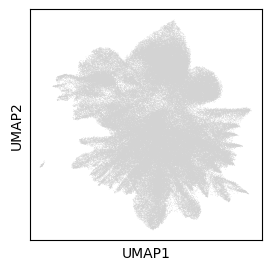

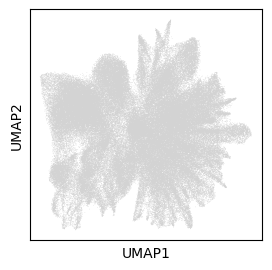

In [12]:
sc.pl.umap(adata)
sc.pl.umap(bdata)

In [13]:
sc.tl.leiden(adata, key_added='leiden_scVI_1', resolution=1)
sc.tl.leiden(bdata, key_added='leiden_scVI_1', resolution=1)

/tmp/ipykernel_2942/1177689734.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added='leiden_scVI_1', resolution=1)


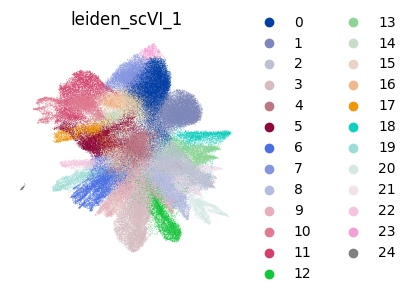

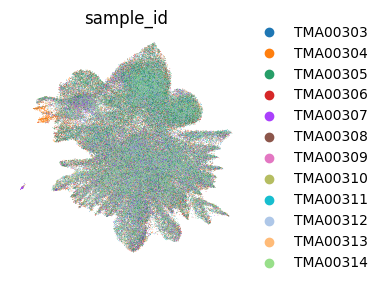

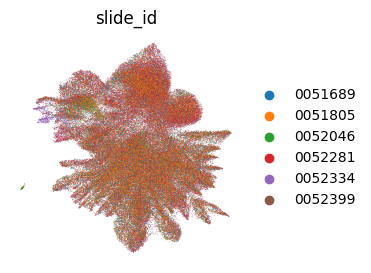

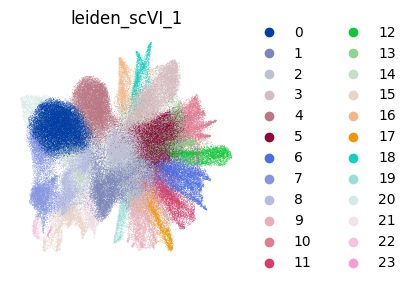

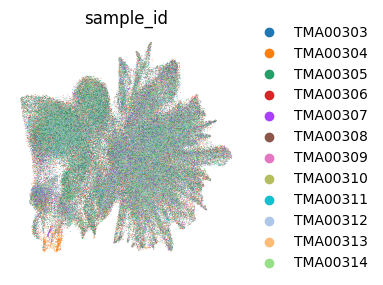

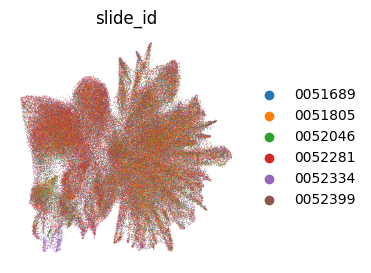

In [14]:
for data in [adata, bdata]:
    sc.pl.umap(data, color=['leiden_scVI_1'], legend_fontsize=10, frameon=False)
    sc.pl.umap(data, color=['sample_id'],     legend_fontsize=10, frameon=False)
    sc.pl.umap(data, color=['slide_id'],         legend_fontsize=10, frameon=False)

### Run DE rankings on clusters

In [15]:
sc.tl.rank_genes_groups(adata, groupby='leiden_scVI_1', method='wilcoxon')
df = sc.get.rank_genes_groups_df(adata, group = None)
df = df.copy()
df = df[(df.pvals_adj < 0.05) & (df.logfoldchanges > .5)].copy()
df.head(5)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Cldn19,167.835678,3.935215,0.0,0.0
1,0,Ncmap,165.734177,3.899224,0.0,0.0
2,0,Prx,164.608246,3.612538,0.0,0.0
3,0,Mbp,162.100250,3.212979,0.0,0.0
4,0,Pllp,161.424179,3.774632,0.0,0.0


In [16]:
clusters_path = os.path.join(clusters_dir, 'rank-genes-clusters.csv')

df.to_csv(clusters_path, index=False)
print(clusters_path)

/home/workspace/projects/drg/clusters/rank-genes-clusters.csv


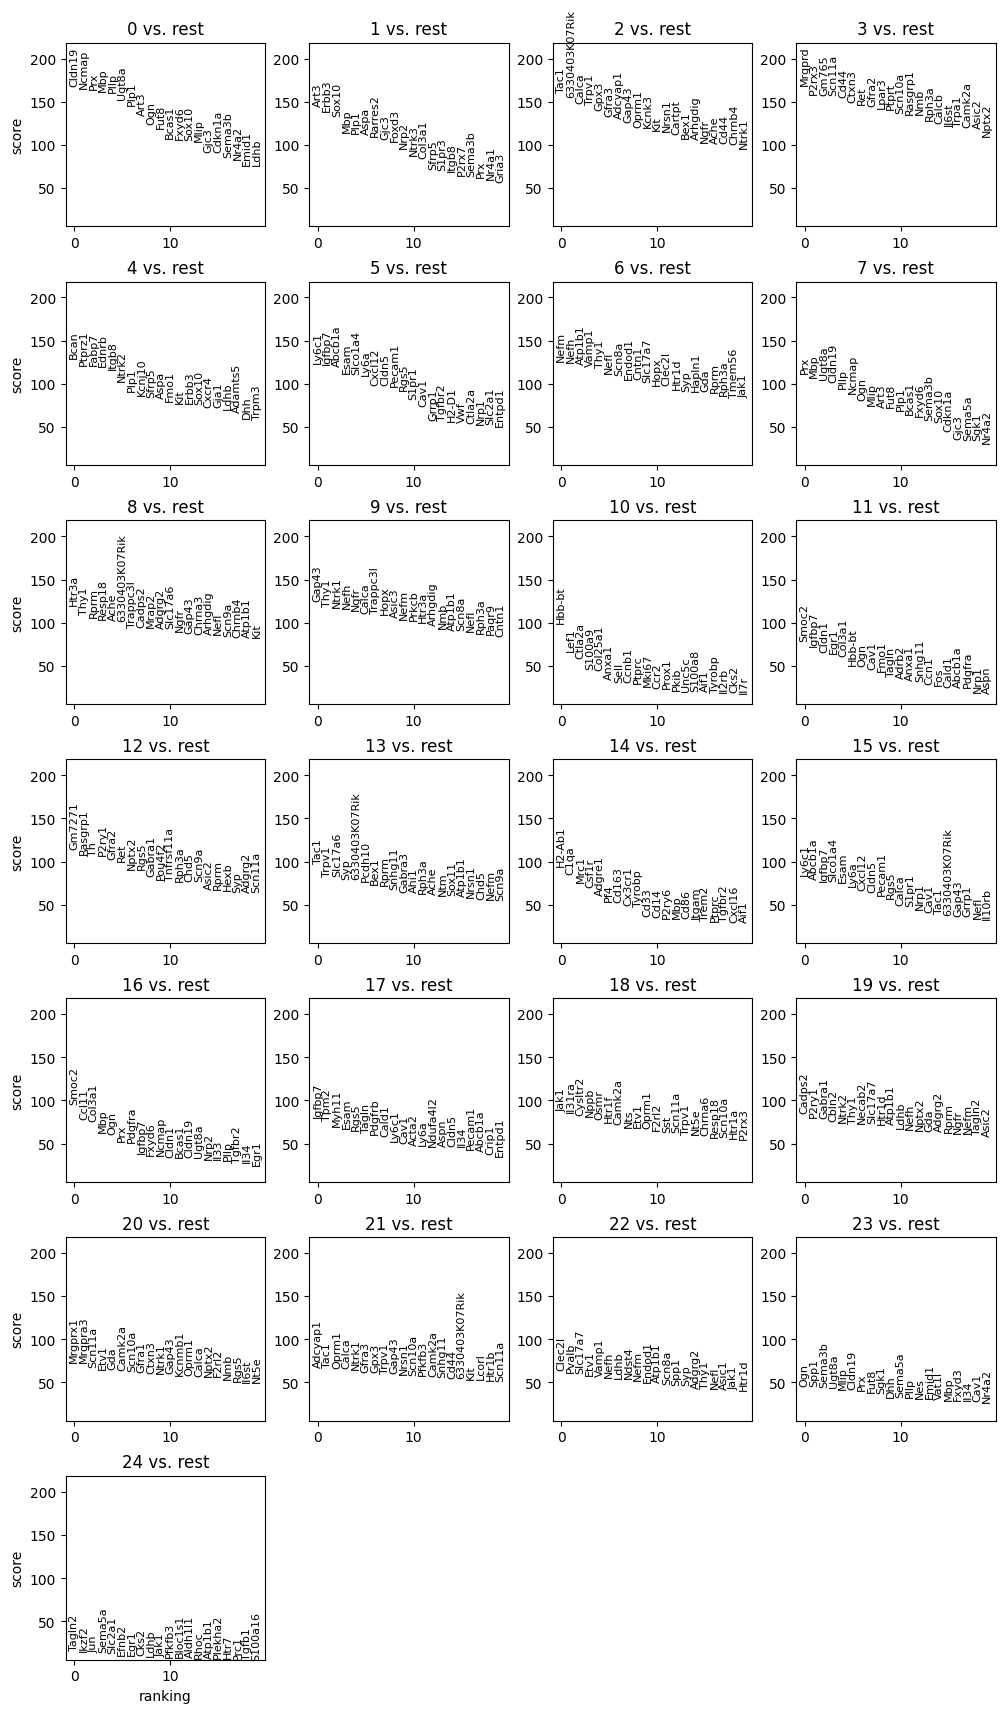

In [17]:
# Visualize top results
sc.pl.rank_genes_groups(adata, groupby = 'leiden_scVI', method = 'wilcoxon')

In [18]:
adata_path = os.path.join(output_dir, 'adata-leiden-475.h5ad')
bdata_path = os.path.join(output_dir, 'adata-leiden-480.h5ad')

adata.write_h5ad(adata_path, compression='gzip')
bdata.write_h5ad(bdata_path, compression='gzip')

print(adata_path)
print(bdata_path)

/home/workspace/projects/drg/data/h5ad/export_02/02b_leiden/adata-leiden-475.h5ad
/home/workspace/projects/drg/data/h5ad/export_02/02b_leiden/adata-leiden-480.h5ad


### Session info

In [19]:
print('active IDE: sc-charter')
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-charter
active conda environment:  sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
